# Sea Level Models: compute the A matrix

Construct the  𝐴 -matrix for the following three different functional models describing the sea level rise phenomenon:









1.   $$ \LARGE E\{\underline{y}\} = l_0 + rΔt_i → A1$$

2.   $$ \LARGE E\{\underline{y}\} = l_0 + a\sin(2\pi \Delta t_i)→ A2$$
3.   $$ \LARGE E\{\underline{y}\} = l_0 + rΔt_i + a\sin(2\pi \Delta t_i) → A3$$

Then compute the forward model.



## Understand the use of the needed libraries and their functions

Learn how:

*   to compute the sine trigonometric function with `numpy`: https://www.geeksforgeeks.org/python/numpy-sin-python/;
*  to calculate 𝜋 with Python: https://www.geeksforgeeks.org/python/calculate-pi-with-python/.






In [1]:
# Import the required libraries
import numpy as np
import matplotlib.pyplot as plt

# Check online how to use the different function of Numpy library to get 𝜋 and compute Sin and Cos functions

pi = 0 # REPLACE THE 0 WITH THE CORRECT EXPRESSION for 𝜋

print('𝜋:',pi)

Sin2pi = 0 # REPLACE THE 0 WITH THE CORRECT EXPRESSION for sin(2𝜋)
Cos2pi = 0 # REPLACE THE 0 WITH THE CORRECT EXPRESSION for cos(2𝜋)

print('sin(2𝜋):',Sin2pi)
print('cos(2𝜋):',Cos2pi)


𝜋: 0
sin(2𝜋): 0
cos(2𝜋): 0


Learn how:

*   to use the `numpy arange` function to create an array of evenly spaced values within a given interval: https://www.geeksforgeeks.org/python/numpy-arrange-in-python/;

*   to use the `numpy scalar` product: https://www.geeksforgeeks.org/machine-learning/numpy-vector-multiplication/;

*   to use the matrix multiplication operator (`@`): https://alysivji.com/python-matrix-multiplication-operator.html, https://www.geeksforgeeks.org/numpy/multiplication-two-matrices-single-line-using-numpy-python/. For `numpy.matmul` (`@`), when the second argument is a 1-D array with shape `(n,)`, NumPy treats it as a column vector with shape `(n, 1)`, performs the matrix multiplication, and then removes the added dimension from the result, returning a 1-D array.


To recall the theory of matrix multiplication, refer to https://en.wikipedia.org/wiki/Matrix_multiplication.



In [2]:
# Understand the use of the Numpy function np.arange and the use of the operator * between numpy array and costant
# Try to print a
# Which kind of variable is a?
a = np.arange(10)*0.1

print('a\n',a)

# Understand the use of the matrix multiplicator operator @

############  First multiplication ##################
# Input two matrices
mat1 = np.array([[1, 6, 5],
                 [3 ,4, 8]])
print('mat1\n', mat1)
print('mat1 shape (rows, cols):', mat1.shape)
mat2 = np.array([[3,  4, 1, 5],
                 [5,  6, 7, 7],
                 [6, 56, 4, 2]]
            )
print('mat2\n', mat2)
print('mat2 shape (rows, cols):', mat2.shape)

# This will return matrix product of two array
res = mat1 @ mat2

# print the result matrix
print('Result of the first matrix multiplication\n',res)
print('Shape of the result of the first matrix multiplication (rows, cols):', res.shape)

############  Second multiplication ##################
# Input two matrices
mat3 = np.array([[1, 6, 5],
                 [3 ,4, 8]])
mat4 = np.array([2, 3, 6])

print('mat3\n', mat3)
print('mat3 shape (rows, cols):', mat3.shape)
print('mat4\n', mat4)
print('mat4 shape (rows, cols):', mat4.shape)

# This will return matrix product of two array
res2 = mat3 @ mat4

print('Result of the second matrix multiplication\n',res2)
print('Shape of the result of the second matrix multiplication (rows, cols):', res2.shape)

a
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
mat1
 [[1 6 5]
 [3 4 8]]
mat1 shape (rows, cols): (2, 3)
mat2
 [[ 3  4  1  5]
 [ 5  6  7  7]
 [ 6 56  4  2]]
mat2 shape (rows, cols): (3, 4)
Result of the first matrix multiplication
 [[ 63 320  63  57]
 [ 77 484  63  59]]
Shape of the result of the first matrix multiplication (rows, cols): (2, 4)
mat3
 [[1 6 5]
 [3 4 8]]
mat3 shape (rows, cols): (2, 3)
mat4
 [2 3 6]
mat4 shape (rows, cols): (3,)
Result of the second matrix multiplication
 [50 66]
Shape of the result of the second matrix multiplication (rows, cols): (2,)


## $$ t_i\ and\ Δt_i $$

Be careful in computing $t_i$ and $Δt_i$.

Use the `arange` function of `numpy`.

Check their lenghts.



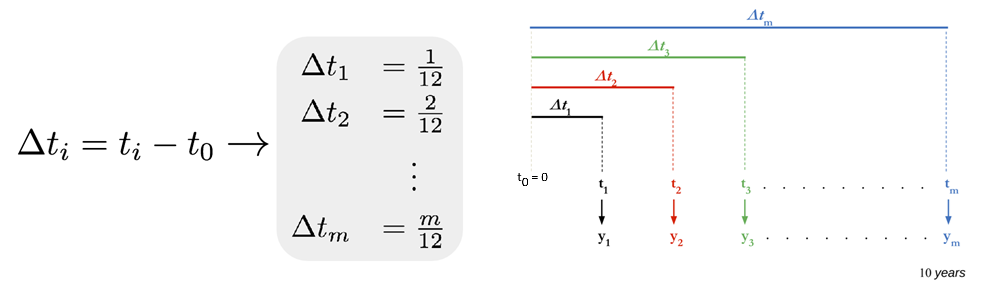

In [3]:
# VECTOR WITH TIMES OF OBSERVATION IN [YEARS]
ti = np.arange(25)*1/12 # change 25 in order to get monthly ti for 10 years
print('ti\n',ti)
print('lenght of ti: ', len(ti))

# VECTOR WITH DELTA TIMES OF OBSERVATION IN [YEARS]
delta_ti = np.arange(1,25)*1/12 # change in order to get monthly delta ti for 10 years
print('Δ_ti\n', delta_ti)
print('lenght of Δ_ti:',len(delta_ti))

# determine the number of observations
m = 0 # REPLACE THE 0 WITH THE CORRECT EXPRESSION
print('number of observations (m):',m)

ti
 [0.         0.08333333 0.16666667 0.25       0.33333333 0.41666667
 0.5        0.58333333 0.66666667 0.75       0.83333333 0.91666667
 1.         1.08333333 1.16666667 1.25       1.33333333 1.41666667
 1.5        1.58333333 1.66666667 1.75       1.83333333 1.91666667
 2.        ]
lenght of ti:  25
Δ_ti
 [0.08333333 0.16666667 0.25       0.33333333 0.41666667 0.5
 0.58333333 0.66666667 0.75       0.83333333 0.91666667 1.
 1.08333333 1.16666667 1.25       1.33333333 1.41666667 1.5
 1.58333333 1.66666667 1.75       1.83333333 1.91666667 2.        ]
lenght of Δ_ti: 24
number of observations (m): 0


##Understand the use of the function np.vstack and the transposition method .T

Learn how:

*   to stack a sequence of input arrays vertically to create a single array using the function `numpy.vstack()`: https://www.geeksforgeeks.org/numpy-vstack-in-python/
*  to transpose a matrix using the method `.T` of numpy arrays: https://www.geeksforgeeks.org/transpose-matrix-single-line-python/
*  to create an array of given shape and type, filled with ones using the function `numpy.ones()`: https://www.geeksforgeeks.org/python/numpy-ones-python/

In [5]:
a = np.arange(10)*10
print('a\n',a)
b= np.arange(10)*0.1
print('b\n',b)

# Understand the use of the function np.vstack and the operation .T
C = np.vstack([a, b]).T
print('c\n',C)

# Understand the use of the function np.ones
uno = np.ones(10)
print('ones\n',uno)

a
 [ 0 10 20 30 40 50 60 70 80 90]
b
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
c
 [[ 0.   0. ]
 [10.   0.1]
 [20.   0.2]
 [30.   0.3]
 [40.   0.4]
 [50.   0.5]
 [60.   0.6]
 [70.   0.7]
 [80.   0.8]
 [90.   0.9]]
ones
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Compute the A matrix for the different models

Compute the A matrix for the different models and print them.

### Linear trend model

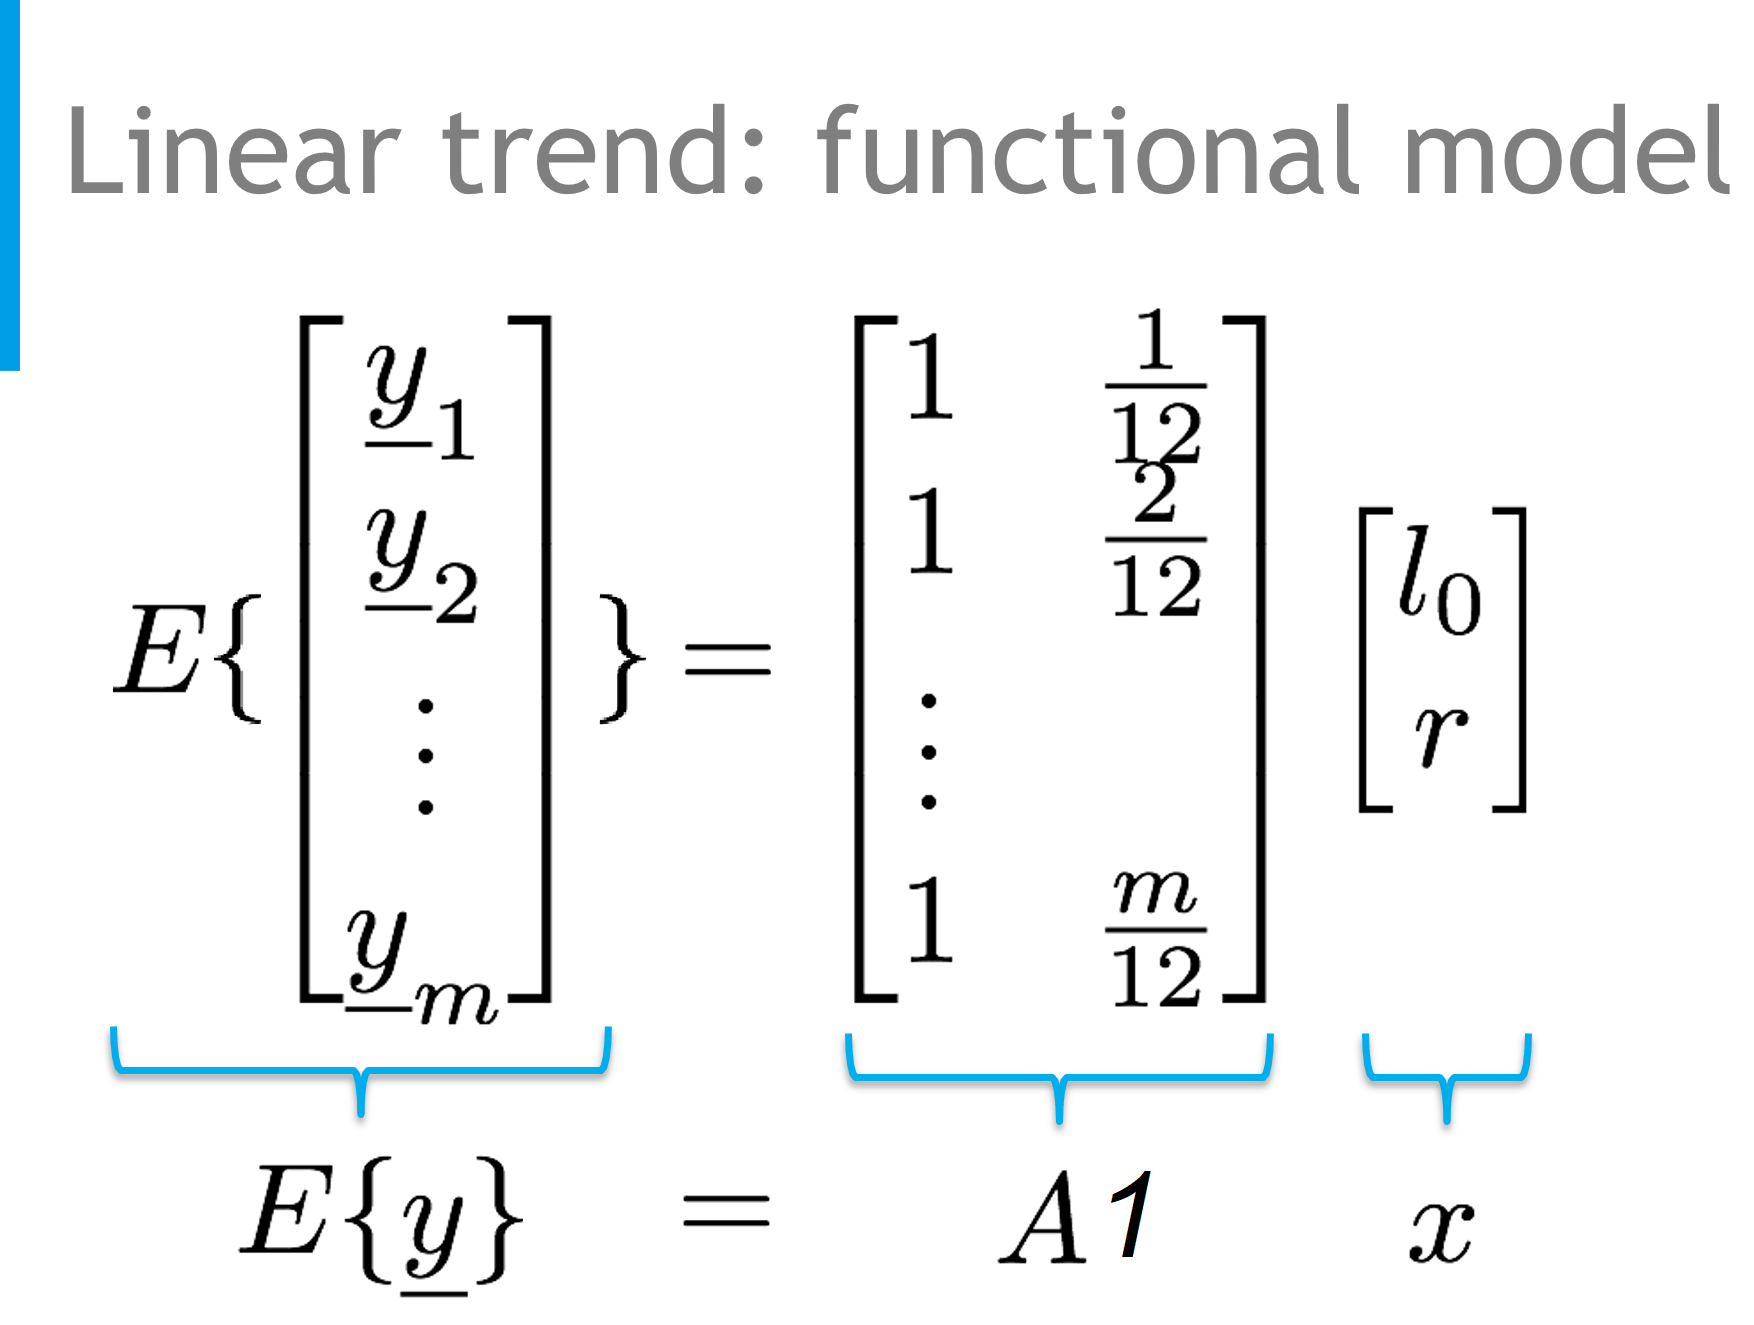


$$ \LARGE E\{\underline{y}\} = l_0 + rΔt_i → A1$$

In [ ]:
#MODEL 1 A-matrix for linear trend model
# The A-matrix in this case is named A1

A1 = 0 # REPLACE THE 0 WITH THE CORRECT EXPRESSION
# print the matrix and the matrix shape
print('A1')
print(A1)
print('A1 shape')
print(A1.shape)

### Annual signal model

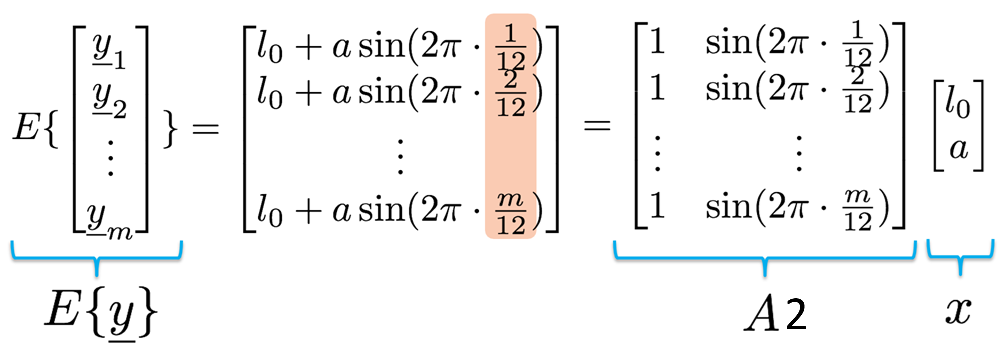

$$ \LARGE E\{\underline{y}\} = l_0 + a\sin(2\pi \Delta t_i)→ A2$$

In [ ]:
# MODEL 2: A-matrix for annual signal model,
# The A-matrix in this case is named A2

# NOTE: if x is a vector, np.sin(x) gives a vector with the sine
# of the individual elements in x

A2 = 0 # REPLACE THE 0 WITH THE CORRECT EXPRESSION
# print the matrix and the matrix shape
print('A2')
print(A2)
print('A2 shape')
print(A2.shape)

### Linear trend + annual signal model



$$ \LARGE E\{\underline{y}\} = l_0 + rΔt_i + a\sin(2\pi \Delta t_i) → A3$$

In [ ]:
# MODEL 3: A-matrix for linear trend + annual signal model,
# The A-matrix in this case is named A3

A3 = 0  # REPLACE THE 0 WITH THE CORRECT EXPRESSION

# print the matrix and the matrix shape
print('A3')
print(A3)
print('A3 shape')
print(A3.shape)


**Q1:** Report the dimensions of the three matrices A.

EDITING THE CELL TO ANSWER

**Q2:** Report the unknown parameters for each of the models and their number.

EDITING THE CELL TO ANSWER

## Forward model



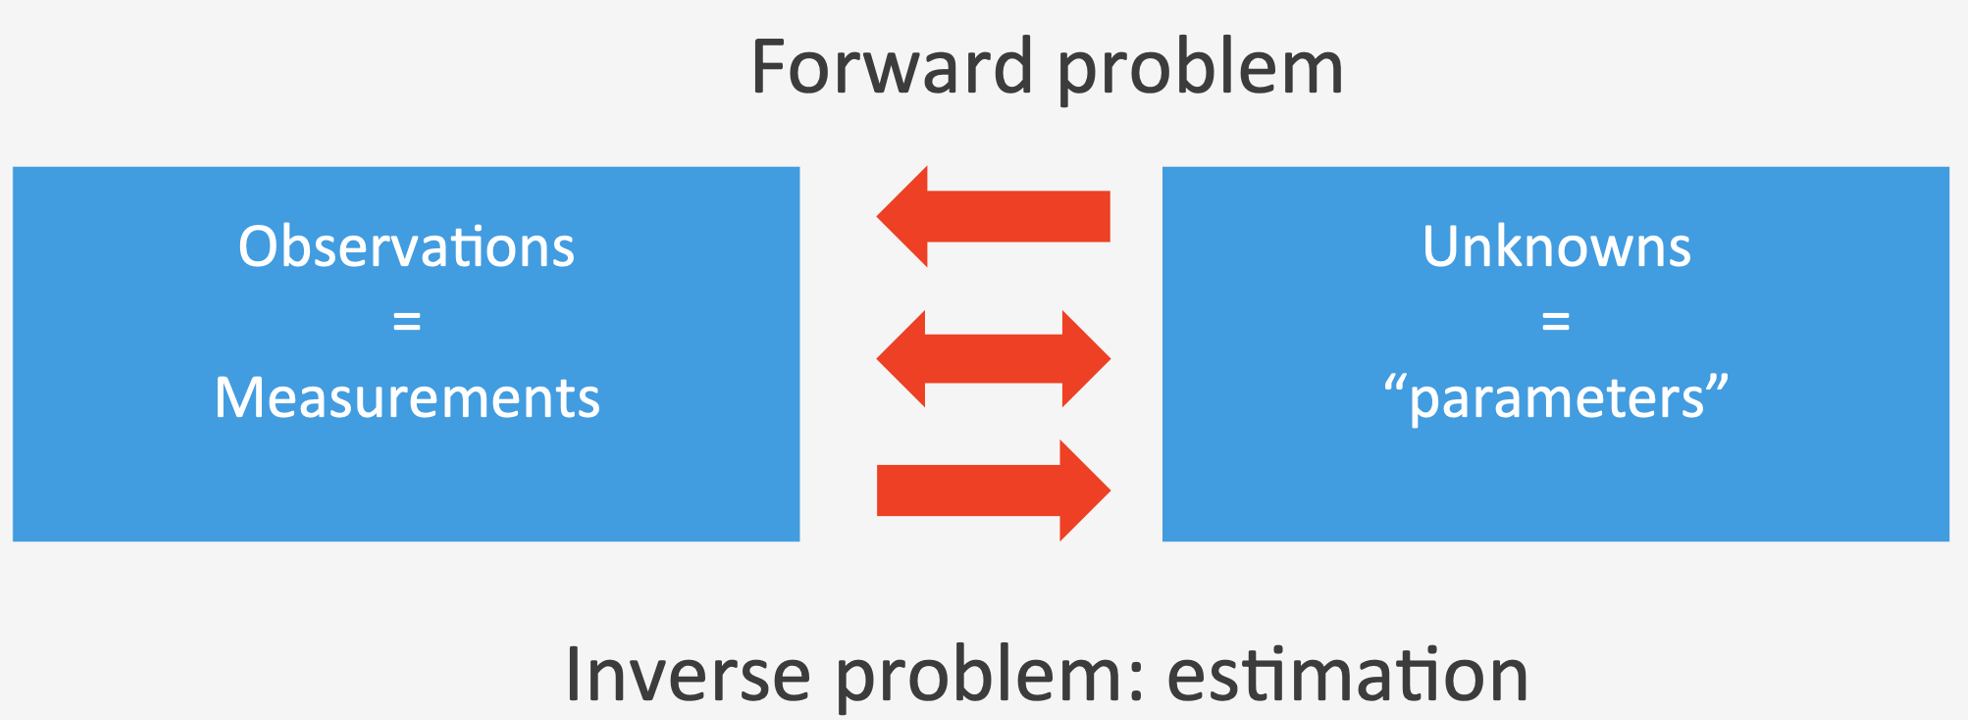



Given the values for the unknowns $x$ (see the following cell), compute $y$:

$y = Ax$.

Use the matrix multiplicator operator (`@`).

In [8]:
# PLOT THE MODEL OUTCOMES for given values of the parameters

l0 = 150 # initial sea level at t0 in [mm]
r  = 0.5 # rate of change in [mm/yr]
a  = 0.1 # amplitude of annual signal in [mm]

x1 = [l0, r]
x2 = [l0, a]
x3 = [l0,  r , a]

# SOLVE FORWARD MODEL y = Ax
# Note: @ operator is a matrix multiplication
# ADD the code to solve the forward models

y1 = 0  # REPLACE THE 0 WITH THE CORRECT EXPRESSION

y2 = 0  # REPLACE THE 0 WITH THE CORRECT EXPRESSION

y3 = 0  # REPLACE THE 0 WITH THE CORRECT EXPRESSION


# ADD the code to print the y vectors of the forward models

**Q3**: Plot the 3 forward models using the `plt.plot()` of `matplotlib`.

When using `plt.plot()`, you might run into the error `ValueError: x and y must have same first dimension`.
This happens if the x-axis and y-axis data don’t have exactly the same length.

Double-check that the two arrays really match in size (for example with `len()` or by inspecting their `.shape`).

A single extra or missing element is enough to break the plot.

In [6]:
# Draw the plots (t,y) for the three models using the function plt.plot of Matplotlib
# i.e.: x axis 	→ [t1, t2, t3, ... , tm]
#       y axis  → [y1, y2, y3, ... , ym]
# Your code here...
